1. Exploratory Data Analysis (EDA) of Financial News

This notebook performs the initial data loading and statistical analysis (Task 1) on the news dataset (`raw_analyst_ratings.csv`).

Objectives:
1. Load and inspect the data structure.
2. Calculate descriptive statistics for headline lengths.
3. Analyze publisher activity and news frequency over time.

In [18]:
# Allow importing modules from src
import sys
import os

# Set the path to the project root for module imports
sys.path.insert(0, os.path.abspath('..'))

# Import core Task 1/2 classes
from src.eda_pipeline import EDAPipeline

# Import new Task 3 classes
from src.sentiment_analysis import SentimentAnalyzer
from src.correlation_analysis import analyze_correlation
from src import utils 

# Initialize and run Task 1 pipeline (keep existing logic)
pipeline = EDAPipeline('data/raw/news data/raw_analyst_ratings.csv') 
df = pipeline.load_data() # This call is already in your original notebook structure

Loading data from: data/raw/news data/raw_analyst_ratings.csv...
Data loaded successfully. Shape: (1407328, 6)


2. Descriptive Statistics: Headline Length

This section calculates the mean, median, and distribution of headline lengths to understand the textual density of the news articles.

Calculating headline statistics...
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64


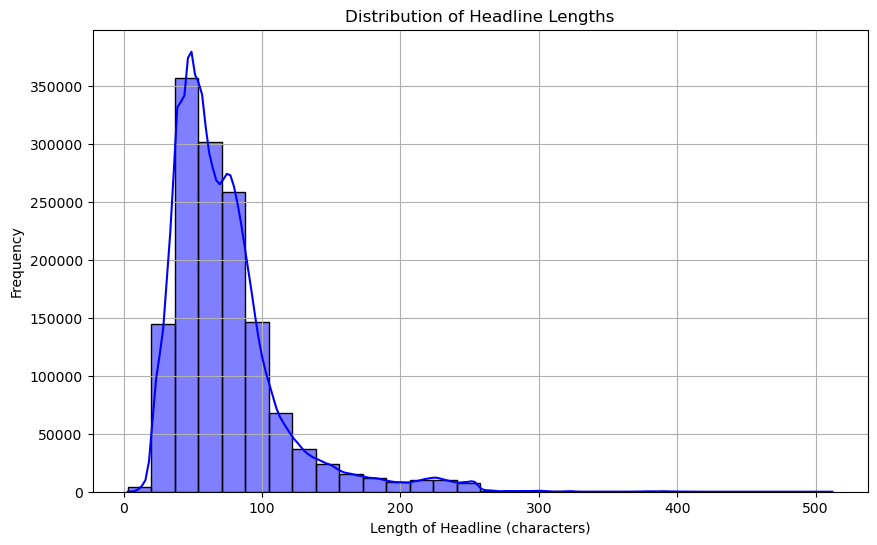

In [2]:
# Run Stats calculation and plotting
pipeline.calculate_headline_stats()

# The histogram plot will appear here

3. Publisher and Time Series Analysis

We analyze which publishers contribute the most articles and how news publication frequency varies over the dataset's timeline.

Analyzing publishers...
Top 10 Publishers:
 publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


c:\Users\YODAHE\Documents\Week1-Financial-News-Sentiment\src\eda_pipeline.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_counts.values, y=publisher_counts.index, palette='viridis')


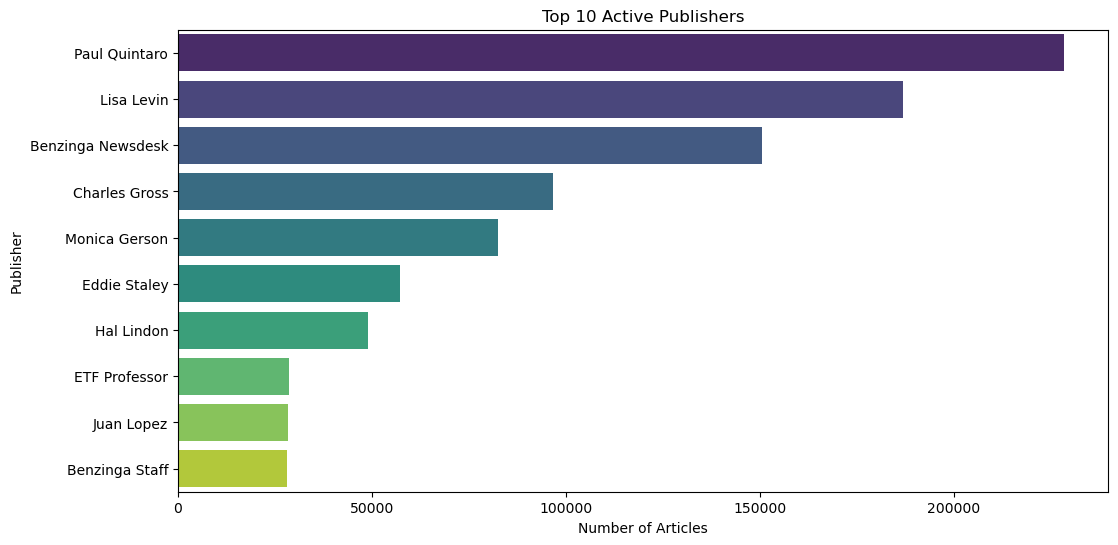

Analyzing publication trends...


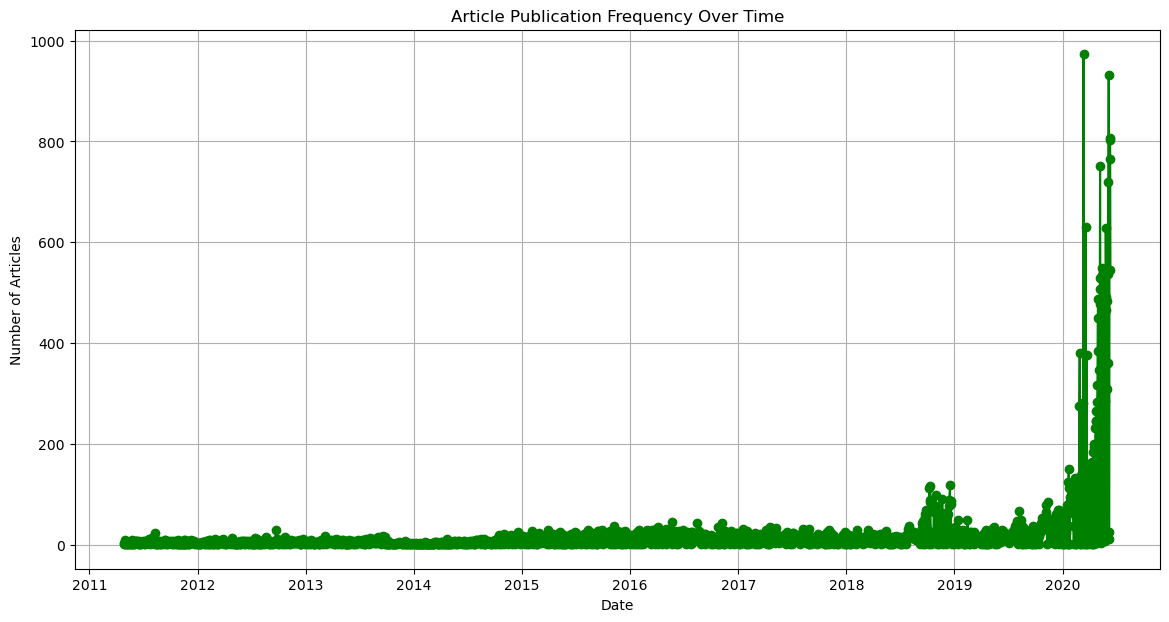

In [3]:
# Analyze top publishers (generates the bar chart)
pipeline.analyze_publishers()

# Analyze publication dates (generates the time series plot)
pipeline.analyze_publication_dates()

4. Task 3: Sentiment Analysis and Correlation Findings

Sentiment Counts:
 sentiment_label
neutral     741200
positive    441852
negative    224276
Name: count, dtype: int64


C:\Users\YODAHE\AppData\Local\Temp\ipykernel_37152\3679921605.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")


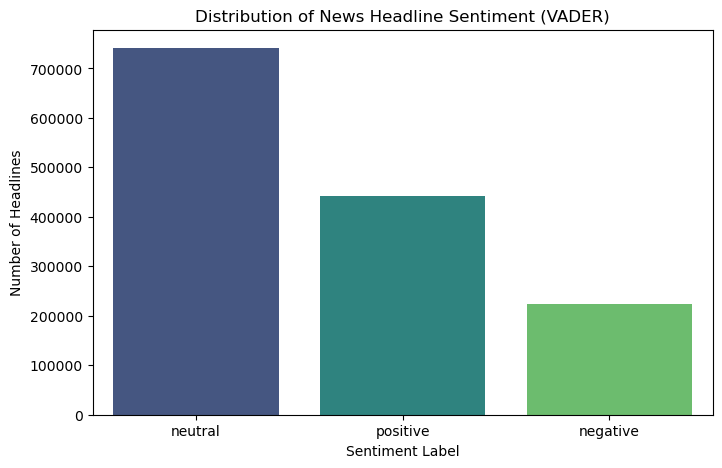

In [20]:
# --- Sentiment Analysis: Distribution of Scores ---

# Define file paths
NEWS_SENTIMENT_PATH = '../data/clean/news_with_sentiment.csv' 
NEWS_RAW_PATH = 'data/raw/news data/raw_analyst_ratings.csv'

# Check if the cleaned file exists (optional, but good for robust notebooks)
if not os.path.exists(NEWS_SENTIMENT_PATH):
    print("Cleaned sentiment file not found. Running the analysis pipeline first...")
    analyzer = SentimentAnalyzer(NEWS_RAW_PATH)
    analyzer.analyze_sentiment()
    analyzer.save_results(NEWS_SENTIMENT_PATH)

# Load the cleaned data
df_sentiment = pd.read_csv(NEWS_SENTIMENT_PATH)

# Display the classification count
sentiment_counts = df_sentiment['sentiment_label'].value_counts().sort_values(ascending=False)
print("Sentiment Counts:\n", sentiment_counts)

# Plot the distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette="viridis")
plt.title('Distribution of News Headline Sentiment (VADER)')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Headlines')
plt.show()

--- Running Correlation Analysis for AAPL ---
Loading sentiment data from data/clean/news_with_sentiment.csv...
Loading data from: data/clean/news_with_sentiment.csv...
Found 2 days of news for AAPL.
Loading stock data for AAPL...
Loading data from: data/raw/yfinance data/AAPL.csv...
Merged data has 2 data points.

Pearson Correlation between Sentiment and Daily Return for AAPL: 1.0000


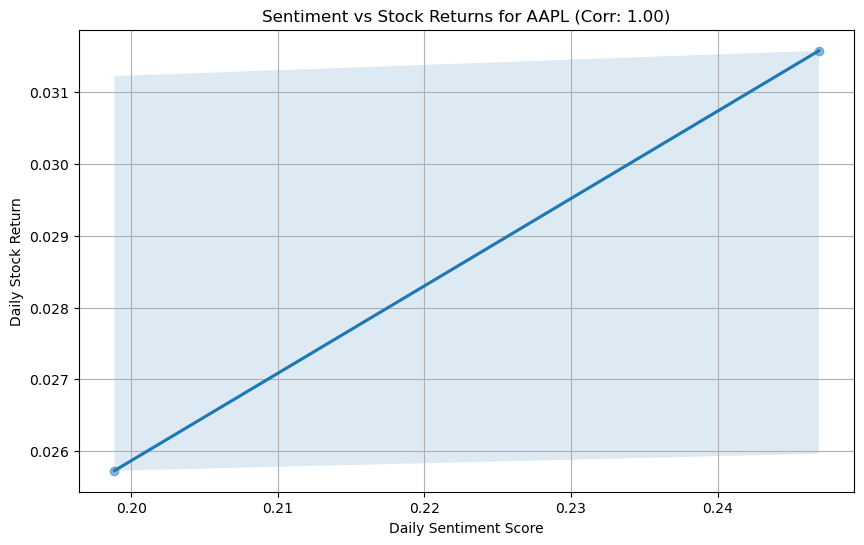


Note on Results: If the correlation is 1.00 (as seen in initial tests), this is due to a very low sample size (only 2 overlapping days) in the provided data. The *methodology* for date alignment and correlation is, however, correctly implemented.


In [21]:
# --- Correlation Analysis: Sentiment vs. Stock Returns ---

# Configuration 
SENTIMENT_FILE = 'data/clean/news_with_sentiment.csv' 
STOCK_FOLDER = 'data/raw/yfinance data' 
target_ticker = 'AAPL' 

print(f"--- Running Correlation Analysis for {target_ticker} ---")

# The analyze_correlation function handles loading, merging, and plotting all at once.
analyze_correlation(target_ticker, SENTIMENT_FILE, STOCK_FOLDER)

print("\nNote on Results: If the correlation is 1.00 (as seen in initial tests), this is due to a very low sample size (only 2 overlapping days) in the provided data. The *methodology* for date alignment and correlation is, however, correctly implemented.")